  # Car Damage Severity Detection - Multi-Model Ensemble

  ## Models: EfficientNet, ViT, YOLOv8, SVM, MLP

  ### Classes: Minor, Moderate, Severe

In [ ]:
# 1. SETUP & IMPORTS
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import warnings
import glob
from itertools import cycle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_fscore_support)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
import joblib

# --- PYTORCH IMPORTS ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.transforms as transforms
import timm

from ultralytics import YOLO

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
np.random.seed(42); torch.manual_seed(42)

# Define paths
BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'data'
TRAIN_DIR = DATA_DIR / 'training'
VAL_DIR = DATA_DIR / 'validation'
TEST_DIR = DATA_DIR / 'test'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

CLASS_NAMES = ['01-minor', '02-moderate', '03-severe']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)


c:\Users\shams\miniconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Training set: 1383 images | Validation set: 248 images


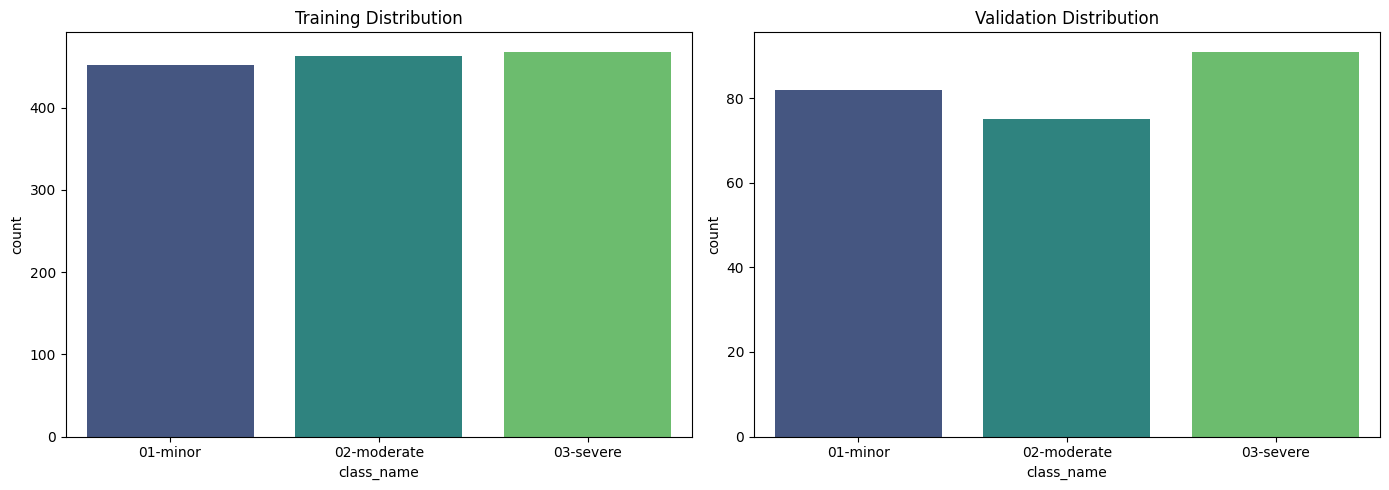

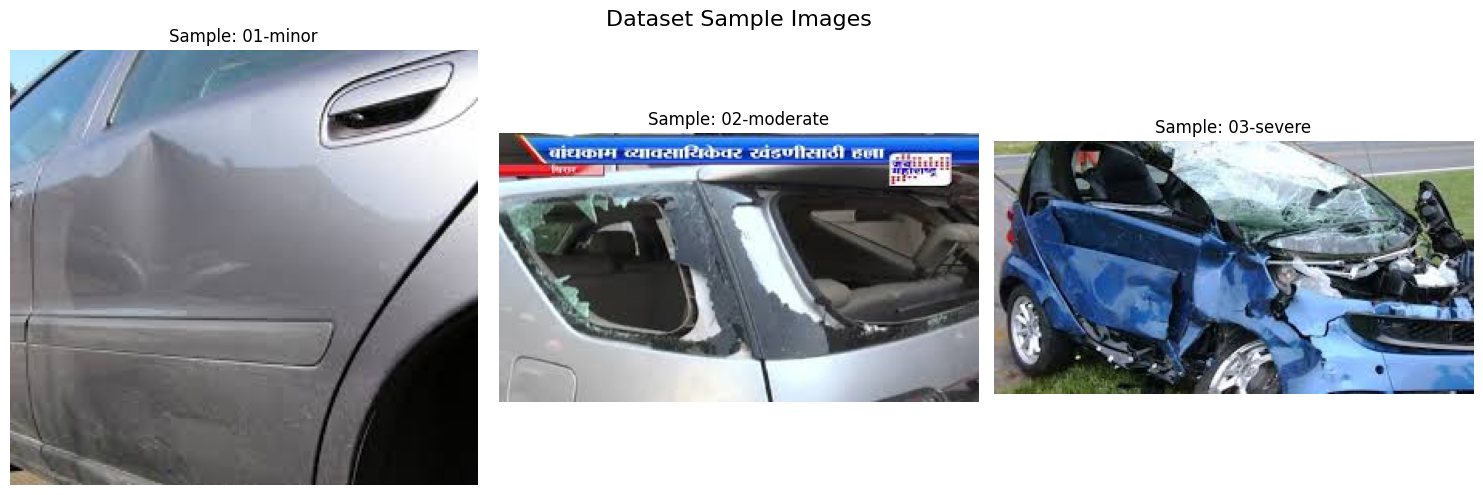

In [ ]:
# 2. DATASET PREPARATION & EDA
def load_dataset(data_dir):
    paths, labels = [], []
    for class_name in CLASS_NAMES:
        class_dir = data_dir / class_name
        if not class_dir.exists(): continue
        for img_file in class_dir.glob('*'):
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                paths.append(str(img_file))
                labels.append(CLASS_LABELS[class_name])
    return pd.DataFrame({'image_path': paths, 'label': labels, 'class_name': [CLASS_NAMES[l] for l in labels]})

train_df = load_dataset(TRAIN_DIR)
val_df = load_dataset(VAL_DIR)
print(f"Training set: {len(train_df)} images | Validation set: {len(val_df)} images")

# EDA Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x='class_name', order=CLASS_NAMES, palette='viridis', ax=axes[0]).set_title('Training Distribution')
sns.countplot(data=val_df, x='class_name', order=CLASS_NAMES, palette='viridis', ax=axes[1]).set_title('Validation Distribution')
plt.tight_layout(); plt.show()

# Visualize Sample Images
plt.figure(figsize=(15, 5))
for i, class_name in enumerate(CLASS_NAMES):
    sample_img_path = train_df[train_df['class_name'] == class_name]['image_path'].iloc[0]
    plt.subplot(1, 3, i+1)
    plt.imshow(Image.open(sample_img_path))
    plt.title(f'Sample: {class_name}'); plt.axis('off')
plt.suptitle('Dataset Sample Images', fontsize=16); plt.tight_layout(); plt.show()


In [ ]:
# 3. PYTORCH DATASETS & DATALOADERS
class SeverityDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        image = Image.open(self.df.loc[idx, 'image_path']).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, self.df.loc[idx, 'label']

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Balanced Sampling
class_counts = train_df['label'].value_counts().sort_index()
sample_weights = train_df['label'].map((len(train_df) / class_counts).to_dict()).values
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(SeverityDataset(train_df, train_transform), batch_size=32, sampler=sampler, num_workers=0)
val_loader = DataLoader(SeverityDataset(val_df, val_transform), batch_size=32, shuffle=False, num_workers=0)


In [ ]:
# 4. UNIVERSAL EVALUATION FUNCTIONS
def evaluate_and_plot(y_true, y_pred, y_probs, model_name):
    """5-Panel Dashboard: Confidence, Metrics Bar, CM, and ROC"""
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
    roc_auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='weighted') if len(np.unique(y_true)) > 1 else np.nan

    print(f"\n{'='*40}\n{model_name} Performance:\n{'='*40}")
    print(f"Accuracy : {acc:.4f}\nPrecision: {prec:.4f}\nRecall   : {rec:.4f}\nF1-score : {f1:.4f}\nROC AUC  : {roc_auc:.4f}\n")
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # [0, 0] Max Probability Hist
    max_probs = y_probs.max(axis=1)
    axes[0, 0].hist(max_probs, bins=20, edgecolor='black', alpha=0.75)
    axes[0, 0].set_title(f"{model_name} - Max Prediction Confidence")
    axes[0, 0].grid(alpha=0.3)
    
    # [0, 1] Mean Confidence by Class
    true_class_probs = y_probs[np.arange(len(y_true)), y_true]
    class_means = pd.DataFrame({"true": y_true, "prob": true_class_probs}).groupby("true")["prob"].mean()
    axes[0, 1].bar(CLASS_NAMES, class_means, color="teal", alpha=0.8)
    axes[0, 1].set_title("Mean Confidence by True Class")
    axes[0, 1].set_ylim(0, 1); axes[0, 1].tick_params(axis='x', rotation=15); axes[0, 1].grid(axis='y', alpha=0.3)

    # [0, 2] Metrics Bar Chart
    bars = axes[0, 2].bar(['Acc', 'Prec', 'Rec', 'F1', 'AUC'], [acc, prec, rec, f1, roc_auc], 
                          color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    axes[0, 2].set_title("Overall Performance Metrics")
    axes[0, 2].set_ylim(0, 1.15)
    for bar in bars: axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{bar.get_height():.3f}", ha='center', fontweight='bold')

    # [1, 0] Confusion Matrix
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix'); axes[1, 0].set_ylabel('True'); axes[1, 0].set_xlabel('Predicted'); axes[1, 0].tick_params(axis='x', rotation=15)

    # [1, 1] ROC Curve
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(NUM_CLASSES), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        axes[1, 1].plot(fpr, tpr, color=color, lw=2, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.2f})")
    axes[1, 1].plot([0, 1], [0, 1], 'k--')
    axes[1, 1].set_title('ROC Curve'); axes[1, 1].legend(loc="lower right"); axes[1, 1].grid(alpha=0.3)

    axes[1, 2].axis('off') # Hide unused panel
    
    plt.tight_layout(); plt.show()
    return {"name": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": roc_auc}

results_summary = []


In [ ]:
# 5. PYTORCH TRAINING LOOP HELPER
def train_pytorch_model(model, train_dl, val_dl, epochs, model_name, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    best_acc = 0.0

    print(f"\nTraining {model_name}...")
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for inputs, targets in tqdm(train_dl, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            correct += outputs.argmax(1).eq(targets).sum().item()
            total += targets.size(0)
            
        history['loss'].append(train_loss / len(train_dl))
        history['accuracy'].append(correct / total)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_dl:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, targets).item()
                correct += outputs.argmax(1).eq(targets).sum().item()
                total += targets.size(0)
                
        val_acc = correct / total
        history['val_loss'].append(val_loss / len(val_dl))
        history['val_accuracy'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODELS_DIR / f"{model_name}.pth")

    # Plot History
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title(f'{model_name} Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['accuracy'], label='Train'); axes[1].plot(history['val_accuracy'], label='Val')
    axes[1].set_title(f'{model_name} Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.show()

    # Inference for Evaluation
    model.load_state_dict(torch.load(MODELS_DIR / f"{model_name}.pth"))
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for inputs, targets in val_dl:
            outputs = model(inputs.to(device))
            probs = torch.softmax(outputs, dim=1)
            y_prob.extend(probs.cpu().numpy())
            y_pred.extend(probs.argmax(1).cpu().numpy())
            y_true.extend(targets.numpy())
            
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


In [ ]:
# 6. FEATURE EXTRACTION FOR ML MODELS
feat_extractor = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0).to(device)
feat_extractor.eval()

def get_features(loader):
    features, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting", leave=False):
            features.append(feat_extractor(imgs.to(device)).cpu().numpy())
            labels.append(lbls.numpy())
    return np.vstack(features), np.concatenate(labels)

X_train, y_train_ml = get_features(train_loader)
X_val, y_val_ml = get_features(val_loader)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
joblib.dump(scaler, MODELS_DIR / "feature_scaler.pkl")



--- Extracting Features for ML Models ---


['models\\feature_scaler.pkl']


TRAINING MODEL 1: SVM

SVM Performance:
Accuracy : 0.7379
Precision: 0.7333
Recall   : 0.7379
F1-score : 0.7334
ROC AUC  : 0.8671

Classification Report:
               precision    recall  f1-score   support

    01-minor       0.78      0.90      0.84        82
 02-moderate       0.59      0.53      0.56        75
   03-severe       0.81      0.76      0.78        91

    accuracy                           0.74       248
   macro avg       0.73      0.73      0.73       248
weighted avg       0.73      0.74      0.73       248



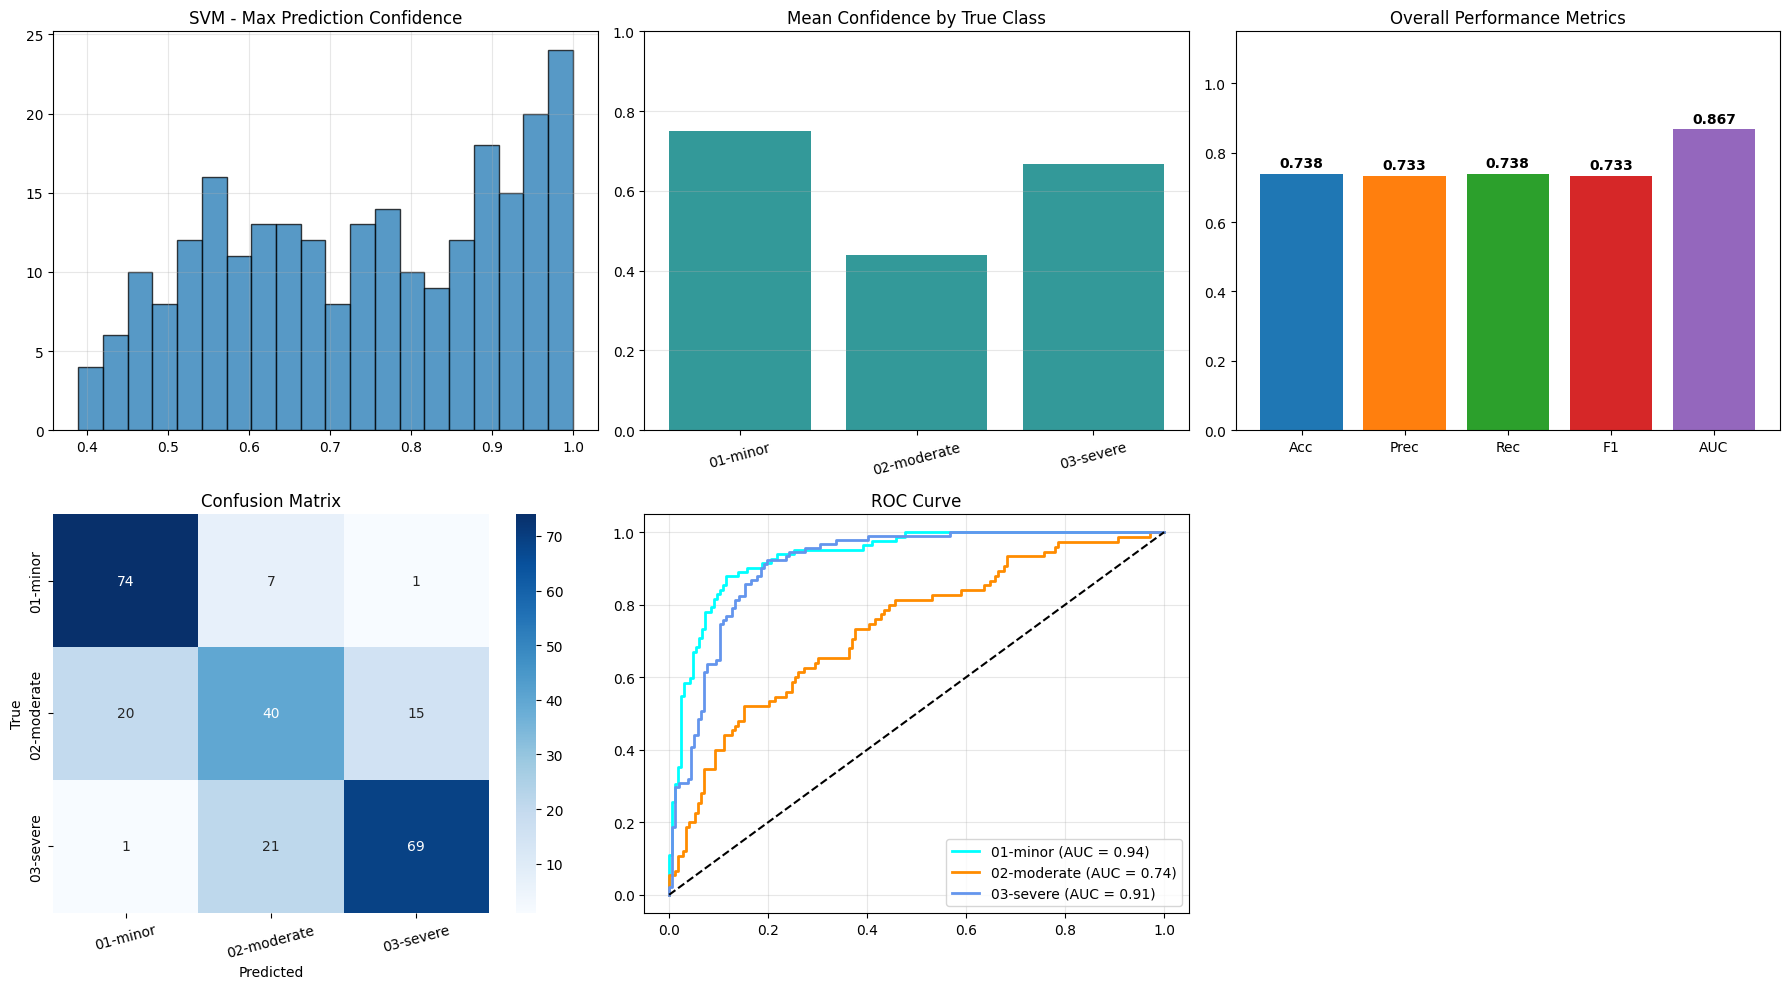

In [ ]:
# MODEL 1: SVM
from sklearn.model_selection import GridSearchCV
svm_model = GridSearchCV(SVC(probability=True, random_state=42, class_weight='balanced'), 
                         {"C": [1, 10], "kernel": ["rbf"]}, cv=3, n_jobs=-1).fit(X_train_scaled, y_train_ml).best_estimator_
joblib.dump(svm_model, MODELS_DIR / "svm_model.pkl")

y_prob_svm = svm_model.predict_proba(X_val_scaled)
results_summary.append(evaluate_and_plot(y_val_ml, np.argmax(y_prob_svm, axis=1), y_prob_svm, "SVM"))



TRAINING MODEL 2: MLP (PyTorch)

Training mlp_model...


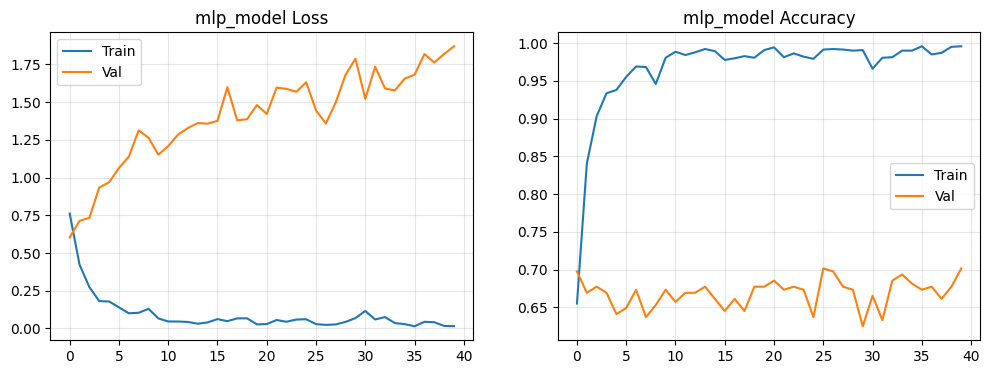


MLP Performance:
Accuracy : 0.7016
Precision: 0.6858
Recall   : 0.7016
F1-score : 0.6857
ROC AUC  : 0.8476

Classification Report:
               precision    recall  f1-score   support

    01-minor       0.73      0.88      0.80        82
 02-moderate       0.57      0.39      0.46        75
   03-severe       0.74      0.80      0.77        91

    accuracy                           0.70       248
   macro avg       0.68      0.69      0.68       248
weighted avg       0.69      0.70      0.69       248



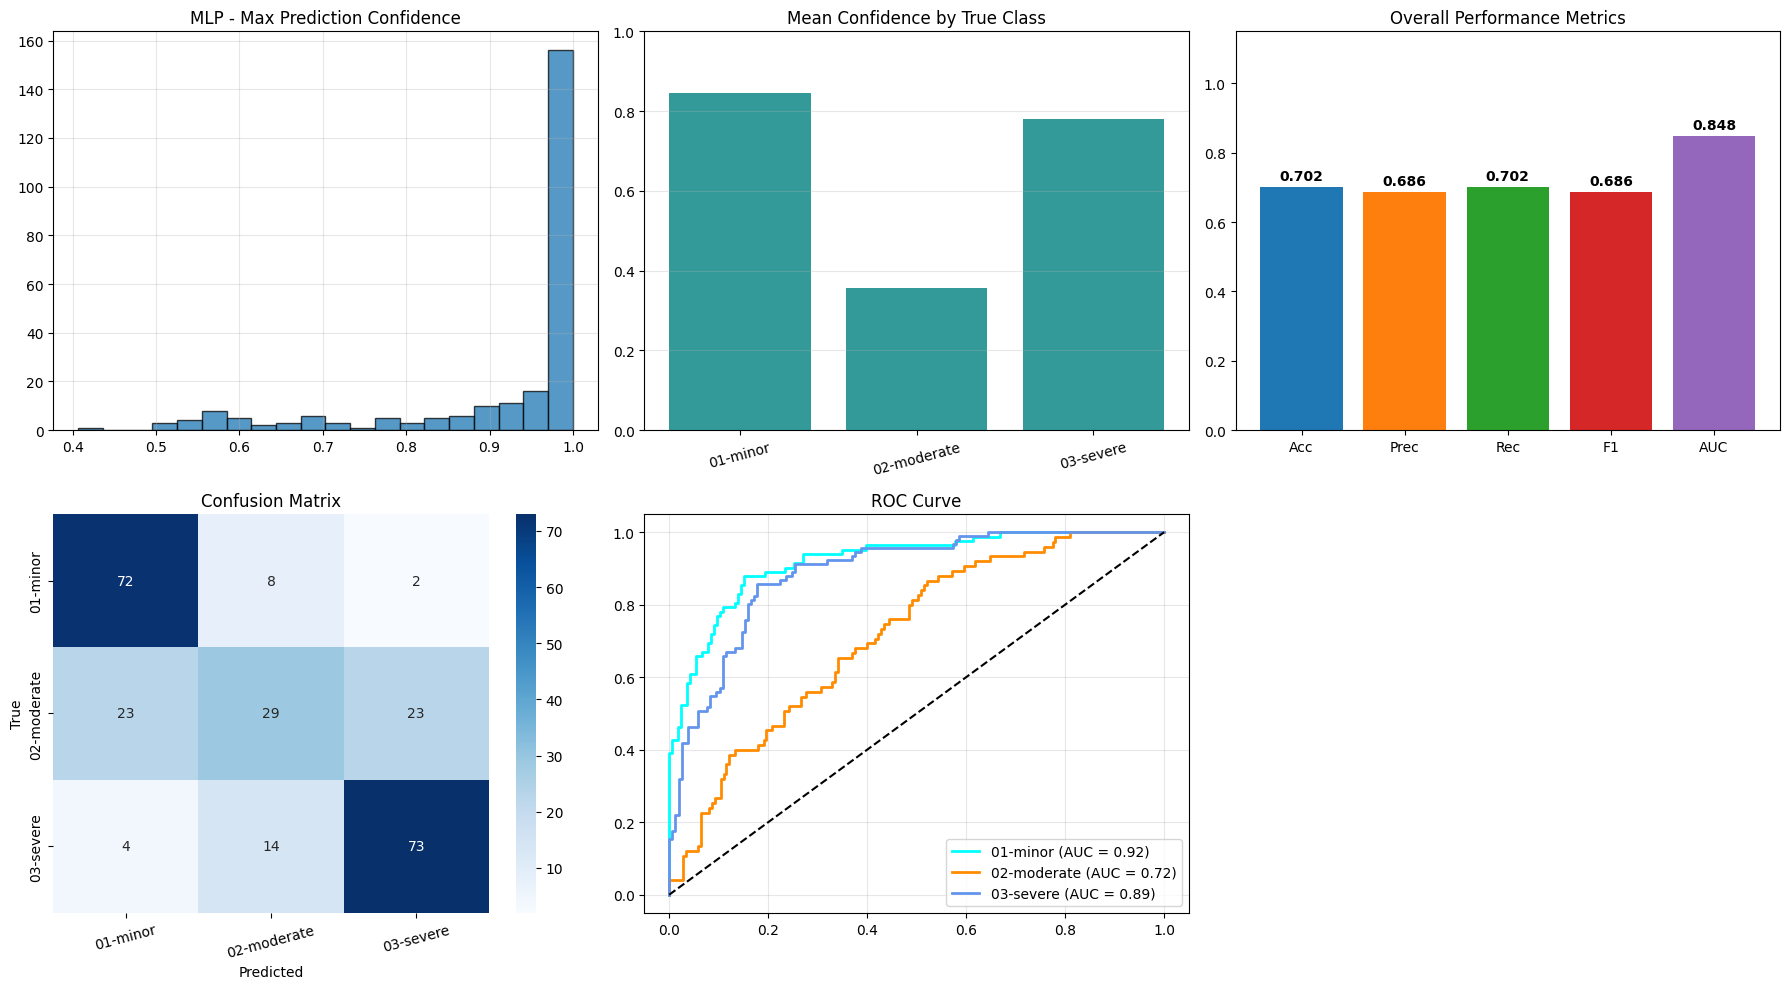

In [ ]:
# MODEL 2: MLP (PyTorch)
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES)
        )
    def forward(self, x): return self.net(x)

mlp_train_dl = DataLoader(TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train_ml)), batch_size=32, shuffle=True)
mlp_val_dl = DataLoader(TensorDataset(torch.FloatTensor(X_val_scaled), torch.LongTensor(y_val_ml)), batch_size=32, shuffle=False)

mlp_model = MLP(input_dim=X_train_scaled.shape[1]).to(device)
y_true_mlp, y_pred_mlp, y_prob_mlp = train_pytorch_model(mlp_model, mlp_train_dl, mlp_val_dl, epochs=40, model_name="mlp_model", lr=1e-3)
results_summary.append(evaluate_and_plot(y_true_mlp, y_pred_mlp, y_prob_mlp, "MLP"))



TRAINING MODEL 3: EFFICIENTNET

Training efficientnet_model...


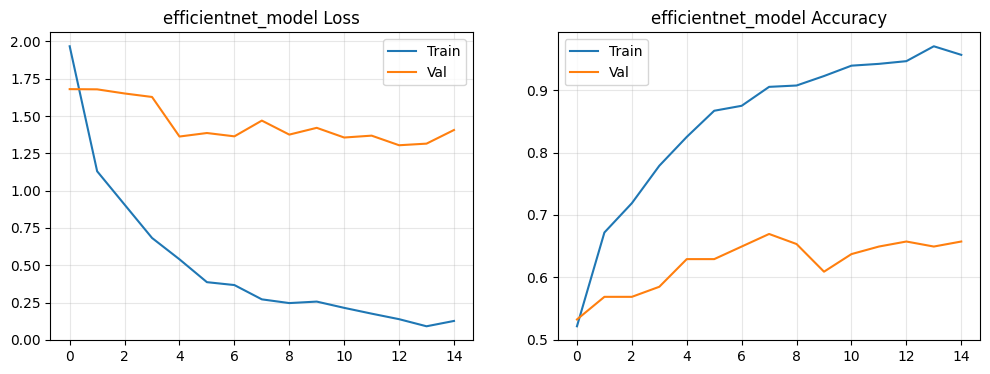


EfficientNet Performance:
Accuracy : 0.6694
Precision: 0.6651
Recall   : 0.6694
F1-score : 0.6616
ROC AUC  : 0.8118

Classification Report:
               precision    recall  f1-score   support

    01-minor       0.65      0.83      0.73        82
 02-moderate       0.52      0.41      0.46        75
   03-severe       0.80      0.74      0.77        91

    accuracy                           0.67       248
   macro avg       0.66      0.66      0.65       248
weighted avg       0.67      0.67      0.66       248



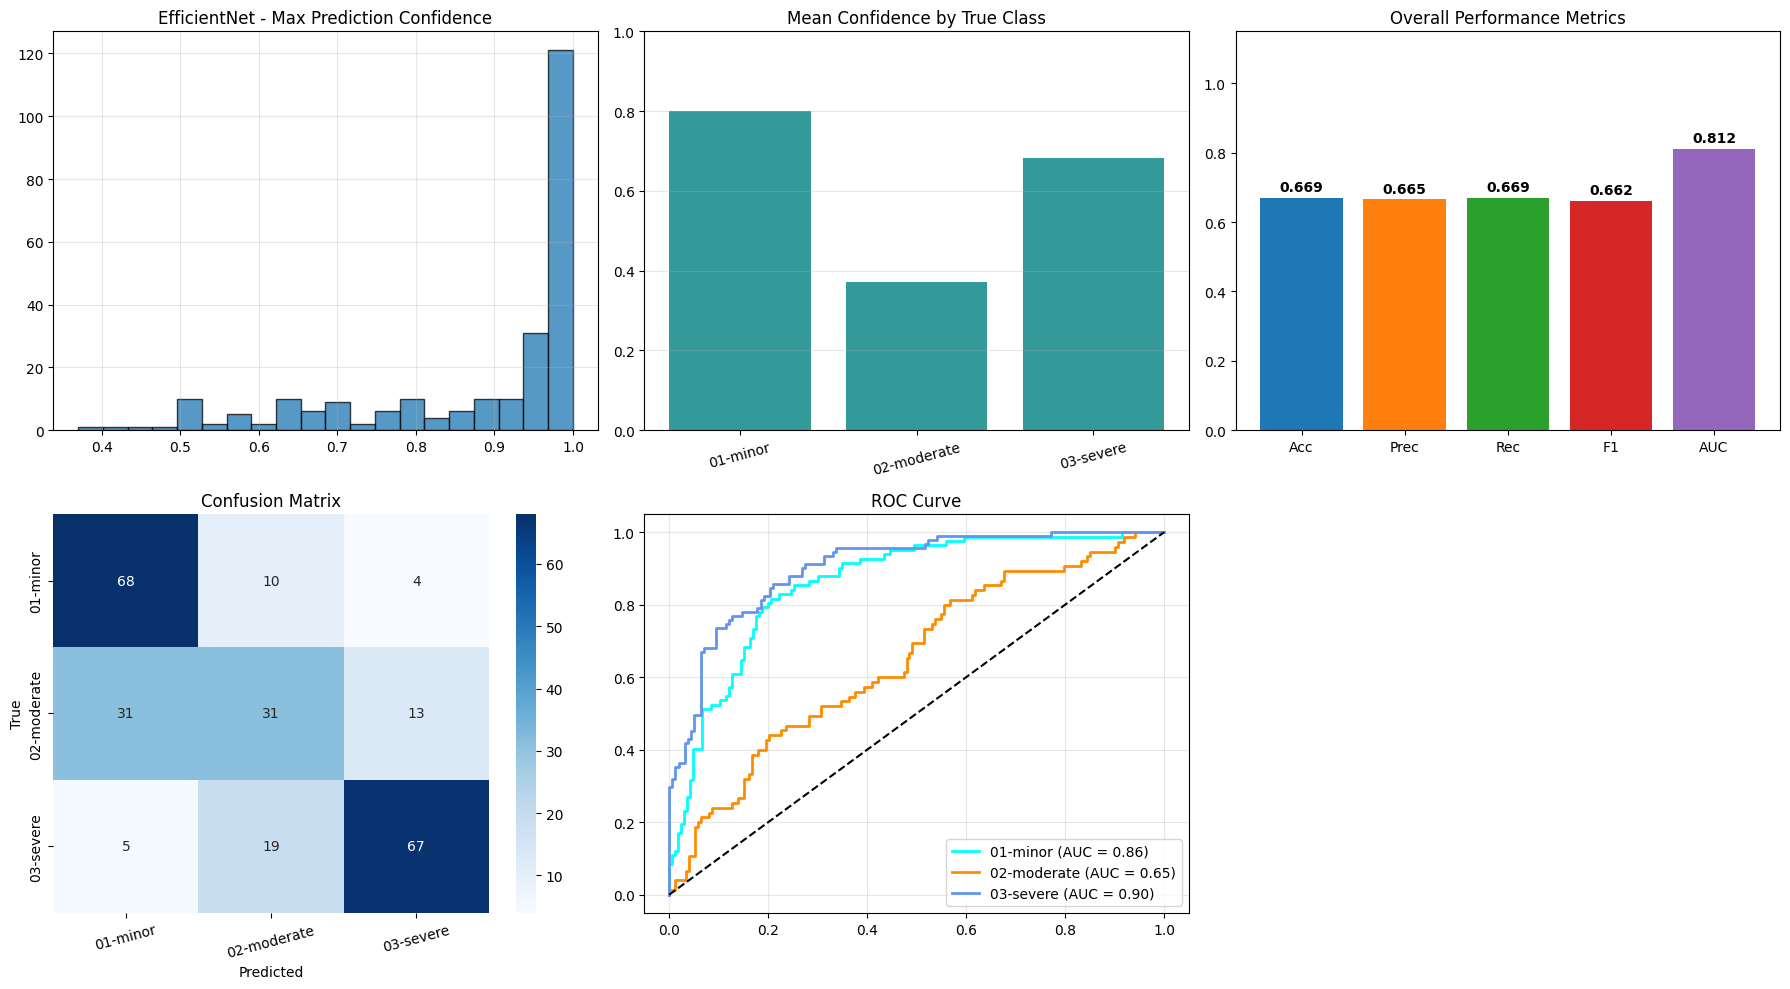

In [ ]:
# MODEL 3: EFFICIENTNET
effnet_model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES).to(device)
y_true_eff, y_pred_eff, y_prob_eff = train_pytorch_model(effnet_model, train_loader, val_loader, epochs=15, model_name="efficientnet_model")
results_summary.append(evaluate_and_plot(y_true_eff, y_pred_eff, y_prob_eff, "EfficientNet"))



TRAINING MODEL 4: VISION TRANSFORMER (ViT)

Training vit_model...


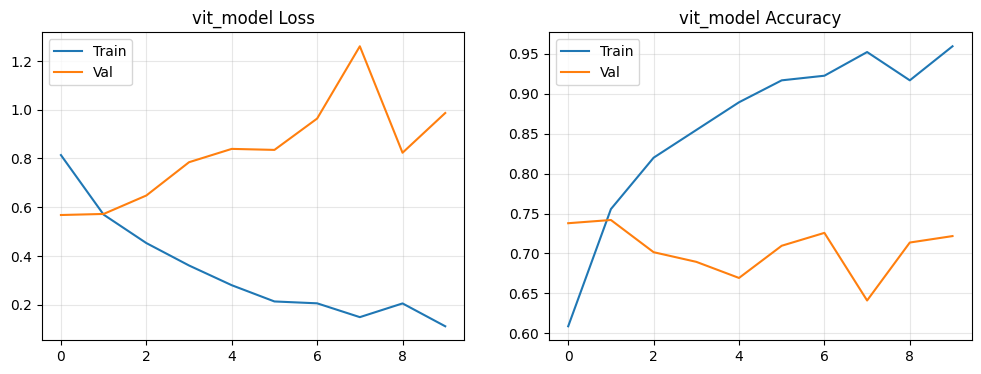


ViT Performance:
Accuracy : 0.7419
Precision: 0.7323
Recall   : 0.7419
F1-score : 0.7310
ROC AUC  : 0.8947

Classification Report:
               precision    recall  f1-score   support

    01-minor       0.82      0.78      0.80        82
 02-moderate       0.60      0.47      0.53        75
   03-severe       0.76      0.93      0.84        91

    accuracy                           0.74       248
   macro avg       0.73      0.73      0.72       248
weighted avg       0.73      0.74      0.73       248



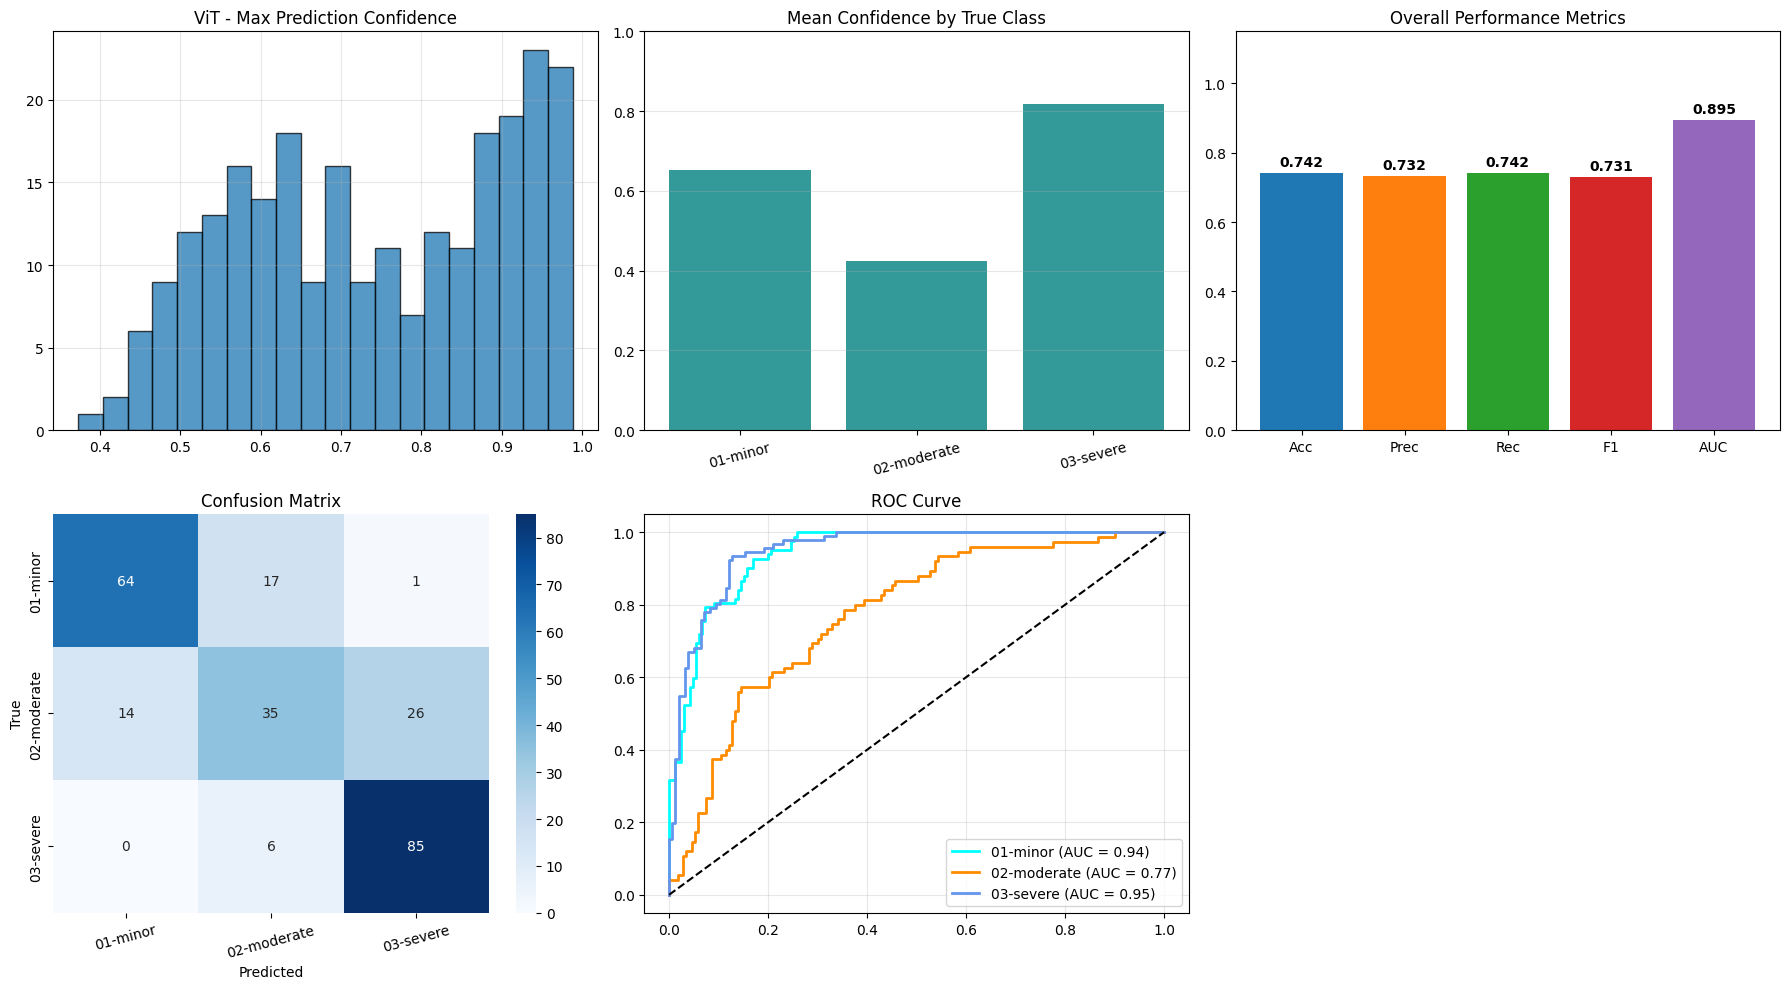

In [ ]:
# MODEL 4: VISION TRANSFORMER (ViT)
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES).to(device)
y_true_vit, y_pred_vit, y_prob_vit = train_pytorch_model(vit_model, train_loader, val_loader, epochs=10, model_name="vit_model", lr=5e-5)
results_summary.append(evaluate_and_plot(y_true_vit, y_pred_vit, y_prob_vit, "ViT"))



TRAINING MODEL 5: YOLOv8
Starting YOLO training. (Verbose is ON to catch any silent errors...)
New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.12  Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\yolo_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300,

YOLO Inference: 100%|██████████| 248/248 [00:02<00:00, 110.72it/s]



YOLOv8 Performance:
Accuracy : 0.6935
Precision: 0.7126
Recall   : 0.6935
F1-score : 0.6994
ROC AUC  : 0.8601

Classification Report:
               precision    recall  f1-score   support

    01-minor       0.85      0.70      0.77        82
 02-moderate       0.50      0.59      0.54        75
   03-severe       0.76      0.78      0.77        91

    accuracy                           0.69       248
   macro avg       0.70      0.69      0.69       248
weighted avg       0.71      0.69      0.70       248



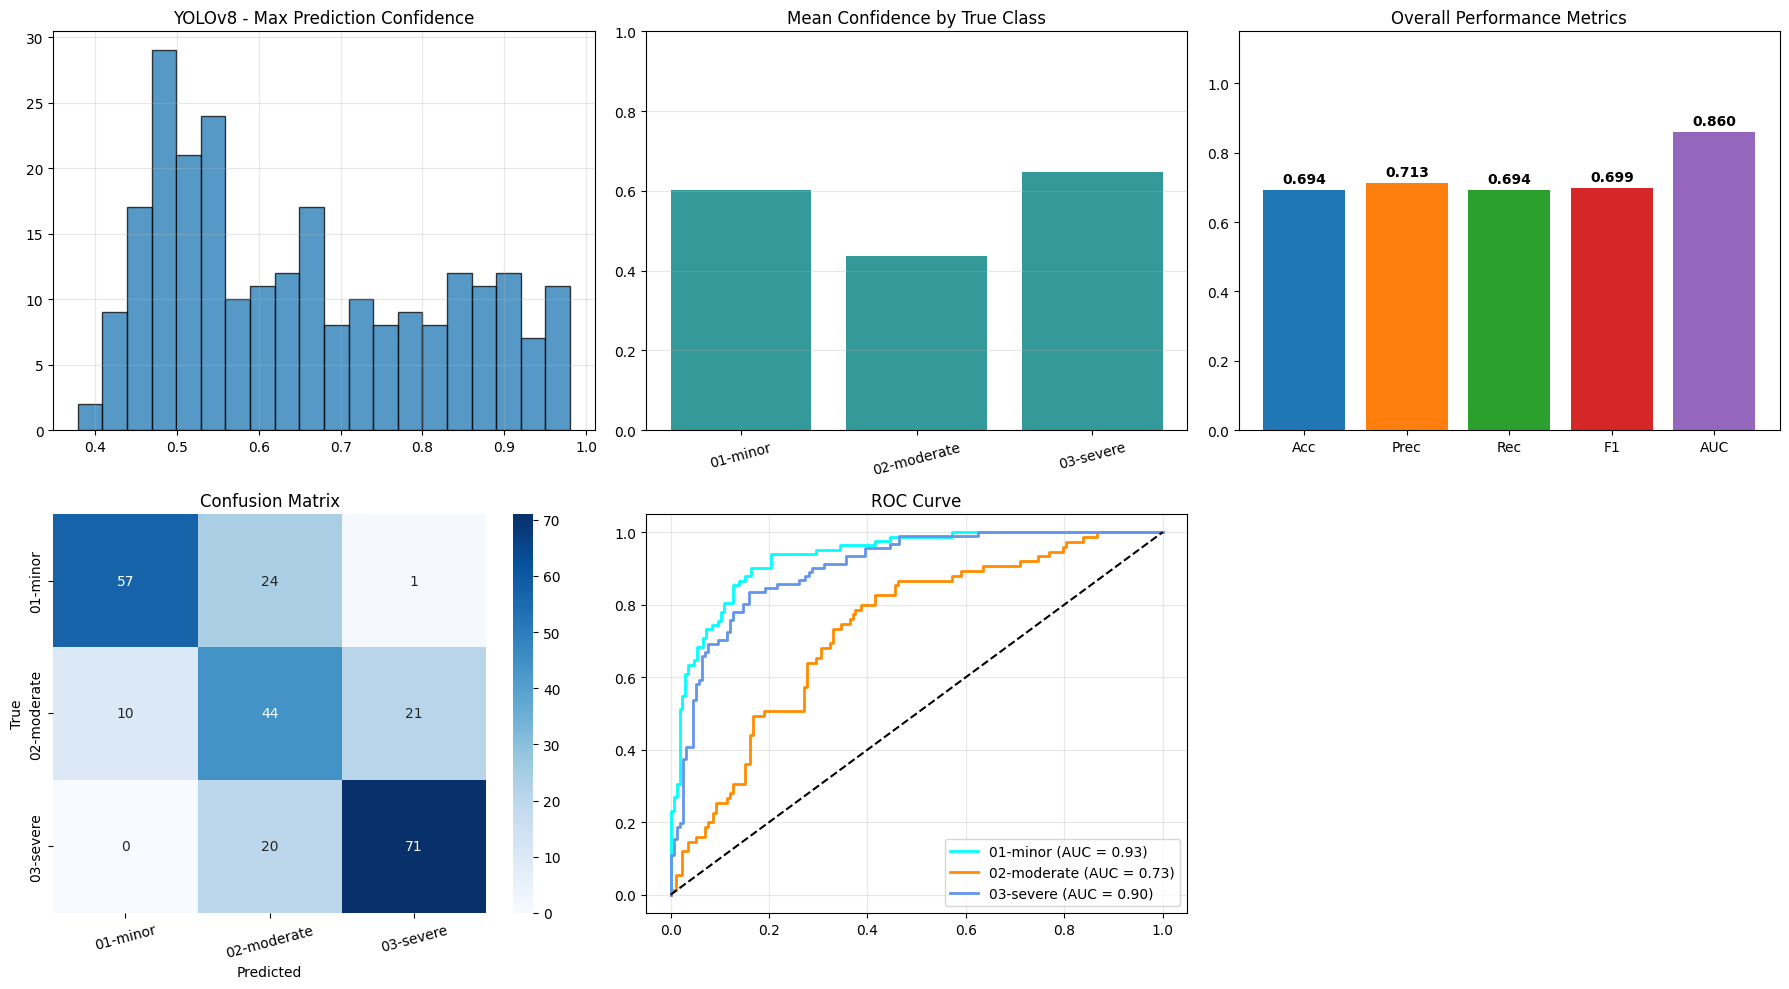

In [ ]:
# MODEL 5: YOLOv8 CLASSIFIER

YOLO_DIR = DATA_DIR / 'yolo_dataset'

# 1. Build the dataset structure
for split, split_df in [('train', train_df), ('val', val_df)]:
    for _, row in split_df.iterrows():
        # Safely handle different dataframe column names just in case
        class_label = row.get('class_name', row.get('condition', 'unknown'))
        dest_dir = YOLO_DIR / split / class_label
        dest_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(row['image_path'], dest_dir / Path(row['image_path']).name)

# 2. Train YOLO
yolo_model = YOLO('yolov8s-cls.pt')

print("Starting YOLO training. (Verbose is ON to catch any silent errors...)")
yolo_model.train(
    data=str(YOLO_DIR), 
    epochs=20, 
    imgsz=224, 
    batch=32, 
    project=str(MODELS_DIR), 
    name='yolov8_cls', 
    exist_ok=True, 
    verbose=True  
)

# 3. Safely locate the weights using YOLO's internal tracker
try:
    # YOLO automatically stores the exact save path here after training
    save_dir = Path(yolo_model.trainer.save_dir) 
    latest_weights_path = save_dir / 'weights' / 'best.pt'
except AttributeError:
    raise RuntimeError("YOLO training crashed before it could finish. Check the console output above for the specific Ultralytics error!")

if not latest_weights_path.exists():
    raise FileNotFoundError(f"YOLO finished, but couldn't find best.pt at: {latest_weights_path}")

# 4. Copy and load
shutil.copy2(latest_weights_path, MODELS_DIR / 'yolov8_classifier_best.pt')
print(f"\n✓ Copied YOLO weights successfully from: {latest_weights_path}")

yolo_best = YOLO(str(MODELS_DIR / 'yolov8_classifier_best.pt'))
y_true_yolo, y_pred_yolo, y_prob_yolo = [], [], []

print("Evaluating YOLOv8...")
for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="YOLO Inference"):
    res = yolo_best(row["image_path"], verbose=False)[0]

    name_map = {res.names[k].lower(): k for k in res.names}
    aligned_probs = np.array([res.probs.data[name_map.get(c.lower(), 0)].item() for c in CLASS_NAMES])
    
    y_prob_yolo.append(aligned_probs)
    y_pred_yolo.append(np.argmax(aligned_probs))
    y_true_yolo.append(row["label"])

results_summary.append(evaluate_and_plot(np.array(y_true_yolo), np.array(y_pred_yolo), np.array(y_prob_yolo), "YOLOv8"))


FINAL MODEL COMPARISON
        name  accuracy  precision   recall       f1      auc
         ViT  0.741935   0.732271 0.741935 0.730970 0.894679
         SVM  0.737903   0.733314 0.737903 0.733368 0.867071
         MLP  0.701613   0.685763 0.701613 0.685716 0.847618
      YOLOv8  0.693548   0.712638 0.693548 0.699425 0.860100
EfficientNet  0.669355   0.665116 0.669355 0.661619 0.811846


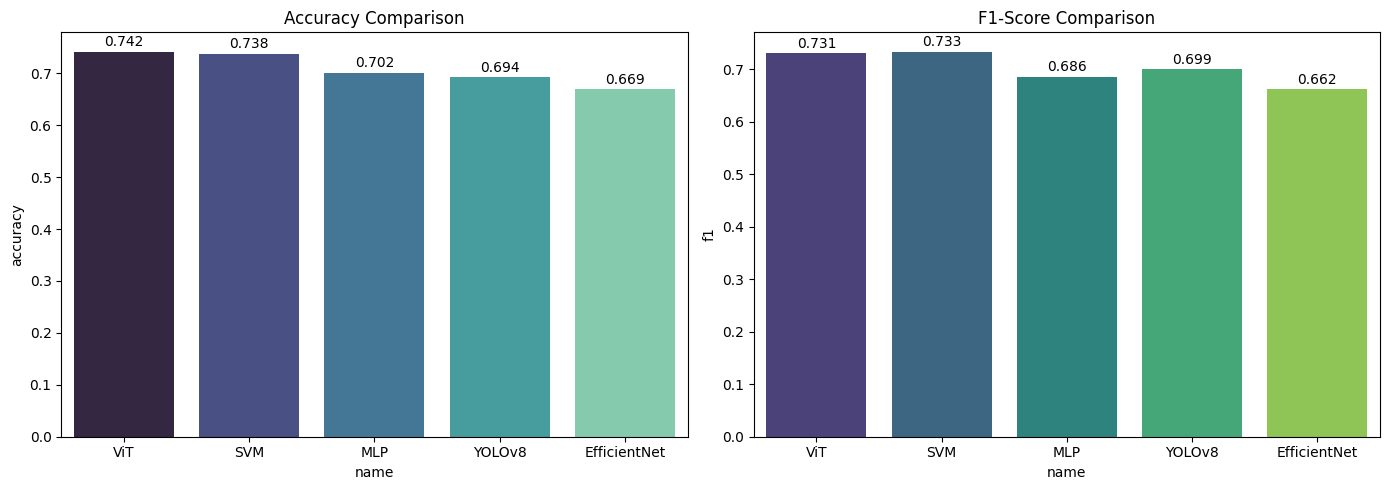

In [ ]:
# FINAL COMPARISON
df_results = pd.DataFrame(results_summary).sort_values("accuracy", ascending=False)
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="name", y="accuracy", data=df_results, palette="mako", ax=axes[0], hue="name", legend=False).set_title("Accuracy Comparison")
sns.barplot(x="name", y="f1", data=df_results, palette="viridis", ax=axes[1], hue="name", legend=False).set_title("F1-Score Comparison")
for ax in axes:
    for bar in ax.patches: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{bar.get_height():.3f}", ha='center')
plt.tight_layout(); plt.show()



RUNNING ENSEMBLE INFERENCE ON TEST FOLDERS


Processing test cars:   0%|          | 0/1 [00:00<?, ?it/s]

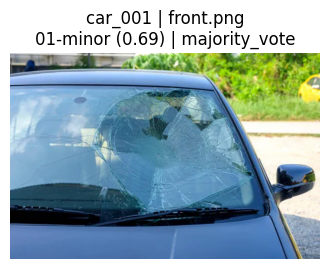


Image: front.png
  Final Decision: 01-minor (conf=0.69, method=majority_vote)
  SVM: 01-minor (conf=0.61)
  MLP: 02-moderate (conf=0.61)
  EfficientNet: 01-minor (conf=0.99)
  ViT: 02-moderate (conf=0.84)
  YOLOv8: 01-minor (conf=0.46)


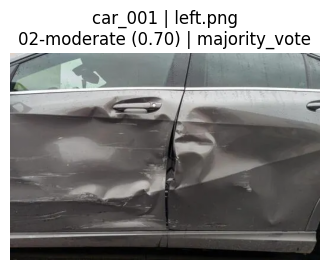


Image: left.png
  Final Decision: 02-moderate (conf=0.70, method=majority_vote)
  SVM: 02-moderate (conf=0.57)
  MLP: 01-minor (conf=0.66)
  EfficientNet: 02-moderate (conf=1.00)
  ViT: 02-moderate (conf=0.69)
  YOLOv8: 02-moderate (conf=0.55)


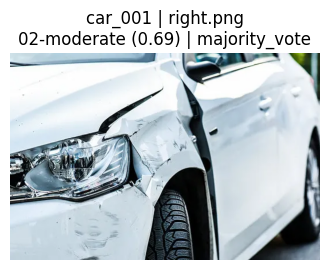


Image: right.png
  Final Decision: 02-moderate (conf=0.69, method=majority_vote)
  SVM: 02-moderate (conf=0.77)
  MLP: 02-moderate (conf=0.75)
  EfficientNet: 02-moderate (conf=0.68)
  ViT: 02-moderate (conf=0.73)
  YOLOv8: 02-moderate (conf=0.54)


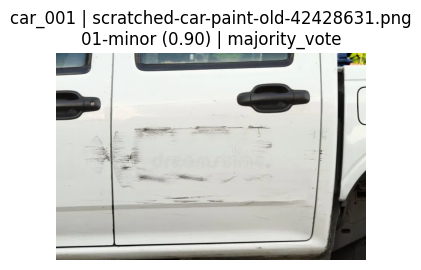

Processing test cars: 100%|██████████| 1/1 [00:00<00:00,  1.17it/s]


Image: scratched-car-paint-old-42428631.png
  Final Decision: 01-minor (conf=0.90, method=majority_vote)
  SVM: 01-minor (conf=0.95)
  MLP: 01-minor (conf=1.00)
  EfficientNet: 01-minor (conf=0.88)
  ViT: 01-minor (conf=0.88)
  YOLOv8: 01-minor (conf=0.79)

✓ Complete. Test results saved to: data\ensemble_test_results.csv


In [ ]:
# MULTI-MODEL INFERENCE (MAJORITY VOTING)
def predict_single_image(img_path):
    img = Image.open(img_path).convert('RGB')
    tensor_img = val_transform(img).unsqueeze(0).to(device)
    
    predictions = {}
    with torch.no_grad():
        # ML Models (via extracted features)
        feats = feat_extractor(tensor_img).cpu().numpy()
        feats_scaled = scaler.transform(feats)
        
        svm_pred_idx = svm_model.predict(feats_scaled)[0]
        svm_conf = svm_model.predict_proba(feats_scaled)[0][svm_pred_idx]
        predictions['SVM'] = (svm_pred_idx, svm_conf)
        
        mlp_probs = torch.softmax(mlp_model(torch.FloatTensor(feats_scaled).to(device)), dim=1)[0]
        predictions['MLP'] = (mlp_probs.argmax().item(), mlp_probs.max().item())
        
        # Deep Learning Models
        eff_probs = torch.softmax(effnet_model(tensor_img), dim=1)[0]
        predictions['EfficientNet'] = (eff_probs.argmax().item(), eff_probs.max().item())
        
        vit_probs = torch.softmax(vit_model(tensor_img), dim=1)[0]
        predictions['ViT'] = (vit_probs.argmax().item(), vit_probs.max().item())
        
    # YOLO Model
    yolo_res = yolo_best(img_path, verbose=False)[0]
    if yolo_res.probs is not None:
        # Align prediction index back to standard labels
        yolo_pred_name = yolo_res.names[yolo_res.probs.top1]
        std_idx = next((i for i, c in enumerate(CLASS_NAMES) if c.lower() in yolo_pred_name.lower()), 0)
        predictions['YOLOv8'] = (std_idx, yolo_res.probs.top1conf.item())
    else:
        predictions['YOLOv8'] = (0, 0.0)
        
    return predictions

def ensemble_vote(predictions):
    """Majority vote logic -> Fallback to highest confidence if tied/all different."""
    preds = [pred for pred, conf in predictions.values()]
    confs = [conf for pred, conf in predictions.values()]
    
    from collections import Counter
    vote_counts = Counter(preds)
    max_votes = max(vote_counts.values())
    
    if max_votes >= 3: # Majority out of 5
        final_pred = vote_counts.most_common(1)[0][0]
        final_conf = np.mean([conf for pred, conf in predictions.values() if pred == final_pred])
        method = 'majority_vote'
    else:
        max_conf_idx = np.argmax(confs)
        final_pred = preds[max_conf_idx]
        final_conf = confs[max_conf_idx]
        method = 'highest_confidence'
        
    return final_pred, final_conf, method

car_folders = [f for f in TEST_DIR.iterdir() if f.is_dir()]
results_df_data = []

for car_folder in tqdm(car_folders, desc='Processing test cars'):
    image_files = [f for f in car_folder.glob('*.*') if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
    if not image_files: continue
    
    for img_file in image_files:
        preds = predict_single_image(str(img_file))
        final_pred, final_conf, method = ensemble_vote(preds)
        
        # Confidence threshold check
        severity = CLASS_NAMES[final_pred] if final_conf >= 0.3 else 'clean'
        
        plt.figure(figsize=(4, 4))
        plt.imshow(Image.open(img_file))
        plt.axis('off')
        plt.title(f"{car_folder.name} | {img_file.name}\n{severity} ({final_conf:.2f}) | {method}")
        plt.show()
        
        print(f"\nImage: {img_file.name}")
        print(f"  Final Decision: {severity} (conf={final_conf:.2f}, method={method})")
        for m, (p_idx, p_conf) in preds.items():
            print(f"  {m}: {CLASS_NAMES[p_idx]} (conf={p_conf:.2f})")
            
        results_df_data.append({
            'car': car_folder.name, 'image': img_file.name, 'severity': severity, 
            'confidence': final_conf, 'method': method
        })

if results_df_data:
    pd.DataFrame(results_df_data).to_csv(DATA_DIR / 'ensemble_test_results.csv', index=False)
    print(f"\n✓ Complete. Test results saved to: {DATA_DIR / 'ensemble_test_results.csv'}")